In [64]:
from sklearn.metrics import mutual_info_score
from os import listdir
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from dit import Distribution
from dit.multivariate import coinformation
import seaborn as sns
from collections import Counter

In [ ]:
def load_data(directory, population, var_of_interest):
    neural_act = []
    stim_id = []
    for f in listdir('./neural_activity/Scale1/' + directory + population + var_of_interest):
        neural_act.append(np.genfromtxt('./neural_activity/Scale1/' + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, np.asarray(stim_id, dtype=int)

In [23]:
def load_spiketimes(directory, population, rank):
    neural_act = []
    stim_id = []
    for f in listdir('./neural_activity/Scale1/' + directory + population + '/spike_time'):
        sp_time = np.genfromtxt('./neural_activity/Scale1/' + directory + population + '/spike_time' + '/' + f, delimiter=',')
        sp_time = np.unique(sp_time)[rank]
        neural_act.append(sp_time)
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, np.asarray(stim_id, dtype=int)


In [5]:
def load_spiketime_per_neuron(directory, population, populationsize, rank):
    neuron_ids, stim_id = load_data(directory, population, '/spike_id')
    neuron_sptime, _ = load_data(directory, population, '/spike_time')
    sp_time_per_neuron = np.zeros((len(stim_id), populationsize))
    for j in range(len(stim_id)):
        #sp_time_per_neuron_per_stim = []
        for i in range(populationsize):
            #sp_time_per_neuron_per_stim.append(neuron_sptime[j][np.where(neuron_ids[j] == i)])
            try:
                sp_time_per_neuron[j, i] = neuron_sptime[j][np.where(neuron_ids[j] == i)][rank]
            except:
                pass
        #sp_time_per_neuron.append(sp_time_per_neuron_per_stim)
    return sp_time_per_neuron, stim_id

In [6]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [7]:
def make_dist(data):
    data = np.asarray(data)
    uniqueness = np.unique(data)
    prob = np.zeros(len(uniqueness))
    for idx, i in enumerate(uniqueness):
        prob[idx] = sum(data == i)
    return prob/len(uniqueness)

In [138]:
def create_dit_dist(data1, data2, stim_values):
    data = zip(data1, data2, stim_values)

    counts = Counter(data)
    total_count = sum(list(counts.values()))

    outcomes = list(counts.keys())
    probabilities = [count / total_count for count in counts.values()]

    return Distribution(outcomes, probabilities)


In [162]:
import numpy as np
import dit
#from dit import distributions
# Example distribution for testing
close = 0
equal = 0
for i in range(1000):
    X = np.random.randint(0, 3, 100)  # Three possible states (0,1,2)
    Y = np.random.randint(0, 3, 100)
    Z = np.random.randint(0, 3, 100)
    dist = create_dit_dist(X, Y, Z)

    # Using dit's coinformation calculation
    coinf_dit = dit.multivariate.coinformation(dist)

    # Your manual computation (example, make sure you are using the correct formula)
    # This part depends on how you've implemented entropy, joint entropy, etc.
    coinf_manual = co_information(X, Y, Z)

    # Compare results with a tolerance
    close += np.isclose(coinf_dit, coinf_manual, atol=1e-10)
    equal += coinf_dit == coinf_manual # Adjust tolerance as needed
print(close)
print(equal)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\dit\math\ops.py:643: RuntimeWarning: divide by zero encountered in log2
  self.zero = self.log(0)


1000
699


In [163]:
import numpy as np

def compute_joint_distribution(*variables):
    """ Compute the joint probability distribution of multiple discrete variables. """
    stacked_vars = np.column_stack(variables)  # Stack input variables as columns
    unique_vals = [np.unique(var) for var in variables]  # Unique states per variable
    bins = [len(vals) for vals in unique_vals]  # Number of bins per variable
    
    joint_counts, _ = np.histogramdd(stacked_vars, bins=bins)  # Joint histogram
    joint_prob = joint_counts / joint_counts.sum()  # Normalize to get probabilities
    
    return joint_prob

def sh_entropy(*variables):
    """ Compute entropy given one or more discrete variables. """
    prob_dist = compute_joint_distribution(*variables)
    prob_dist = prob_dist[prob_dist > 0]  # Remove zero probabilities
    return -np.sum(prob_dist * np.log2(prob_dist))

def co_information(X, Y, Z):
    """ Compute coinformation using entropy. """
    H_X = sh_entropy(X)
    H_Y = sh_entropy(Y)
    H_Z = sh_entropy(Z)
    H_XY = sh_entropy(X, Y)
    H_XZ = sh_entropy(X, Z)
    H_YZ = sh_entropy(Y, Z)
    H_XYZ = sh_entropy(X, Y, Z)


    co_inf = H_X + H_Y + H_Z - H_XY - H_XZ - H_YZ + H_XYZ

    if np.isclose(co_inf, 0, atol=1e-15):  # Adjust tolerance if necessary
        co_inf = 0
    return co_inf

# Example usage
X = np.random.randint(0, 3, 100)  # Three possible states (0,1,2)
Y = np.random.randint(0, 3, 100)
Z = np.random.randint(0, 3, 100)

coinf = co_information(X, Y, Z)
print(f"Coinformation: {coinf}")


Coinformation: -0.03317791220620592


# Amplitude

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

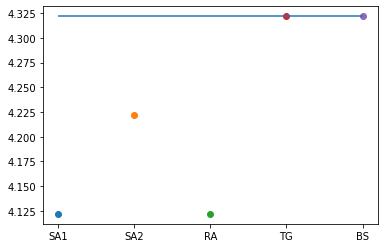

<AxesSubplot:>

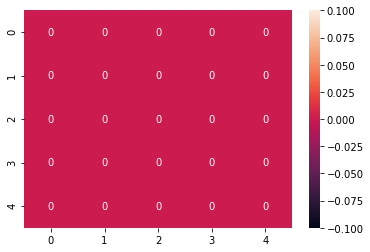

In [166]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
#plt.savefig('./MI/freq_amp.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


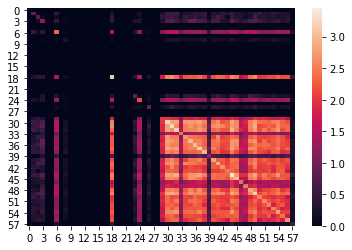

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


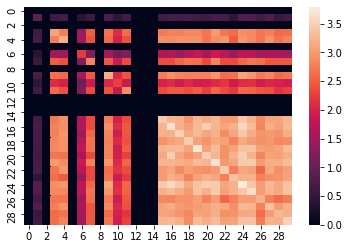

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


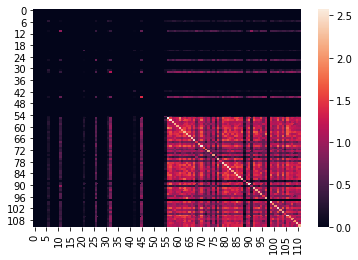

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


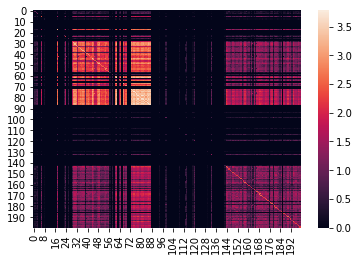

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


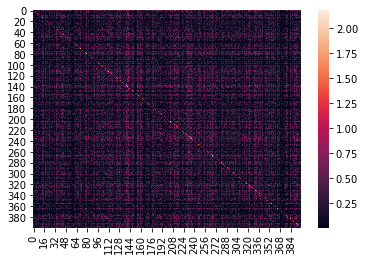

([<matplotlib.axis.XTick at 0x2179f748190>,
 [Text(1, 0, 'SA1'),
  Text(2, 0, 'SA2'),
  Text(3, 0, 'RA'),
  Text(4, 0, 'TG'),
  Text(5, 0, 'BS')])

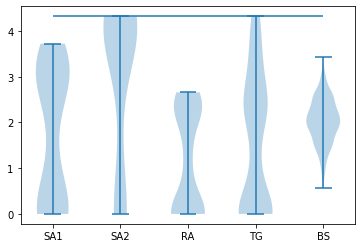

In [165]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_amplitude', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        for k in range(popsize):
            co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    sns.heatmap(co_inf)
    plt.show()
    mi_per_neuron_per_pop.append(mi_per_neuron)
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
#plt.savefig('./MI/single_neuron_amp.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

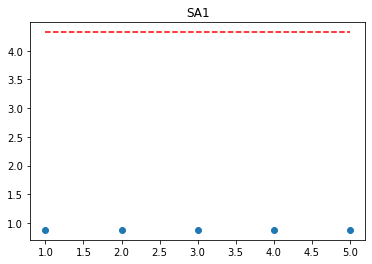

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

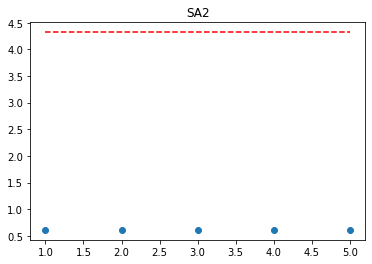

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

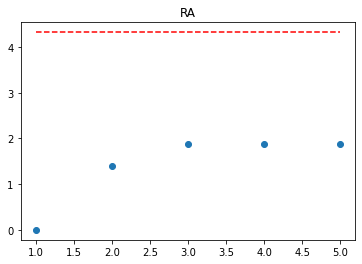

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

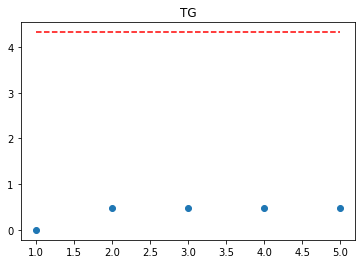

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

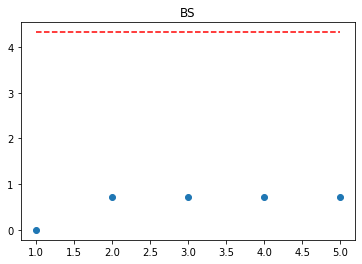

In [39]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_amplitude', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

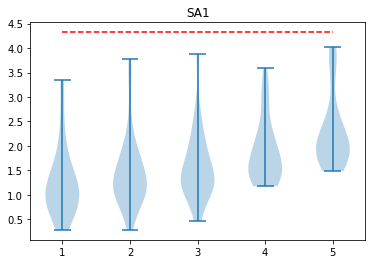

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

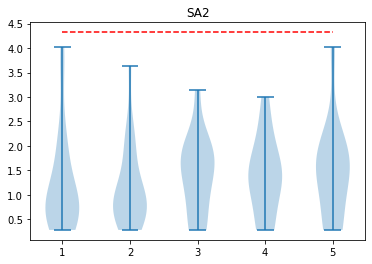

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

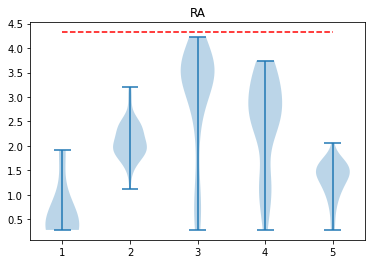

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

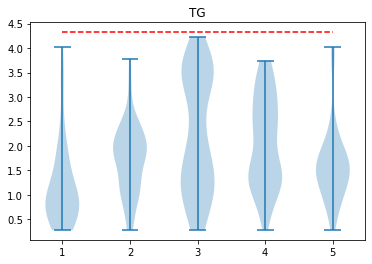

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

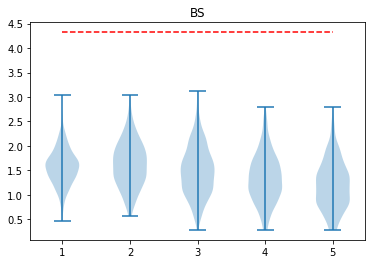

In [56]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    #Within a rank
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_amplitude', '/' + Populations[k], Populations_sizes[k], j)
        #Within a neuron
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Direction

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

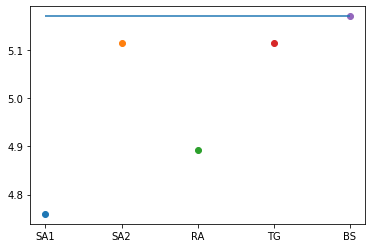

<AxesSubplot:>

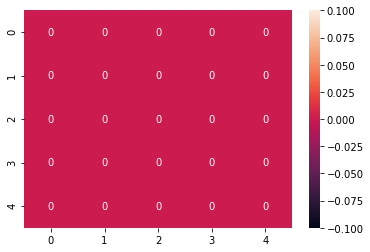

In [167]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
#plt.savefig('./MI/freq_dir.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


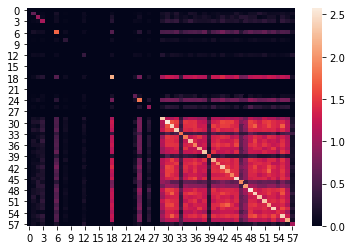

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


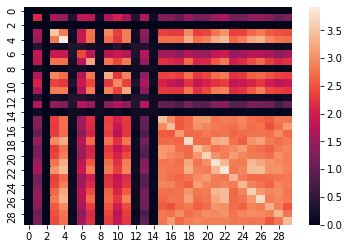

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


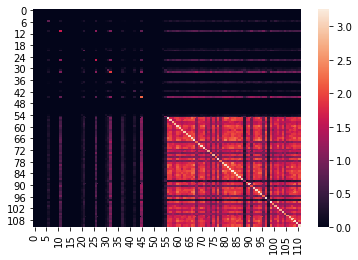

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


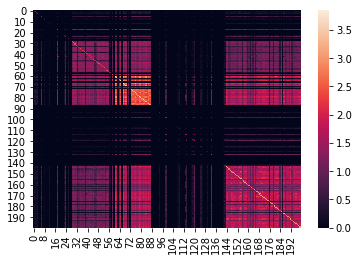

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


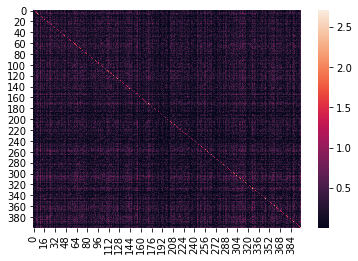

([<matplotlib.axis.XTick at 0x2179e80c940>,
 [Text(1, 0, 'SA1'),
  Text(2, 0, 'SA2'),
  Text(3, 0, 'RA'),
  Text(4, 0, 'TG'),
  Text(5, 0, 'BS')])

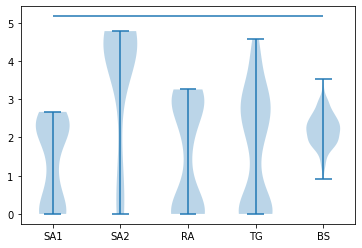

In [168]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_direction', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        for k in range(popsize):
            co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    sns.heatmap(co_inf)
    plt.show()
    mi_per_neuron_per_pop.append(mi_per_neuron)
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
#plt.savefig('./MI/single_neuron_dir.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

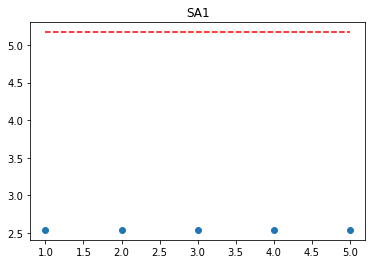

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

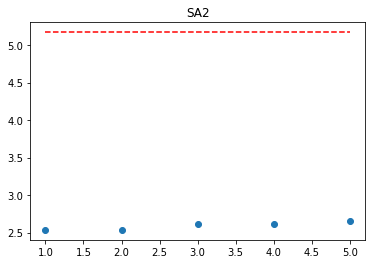

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

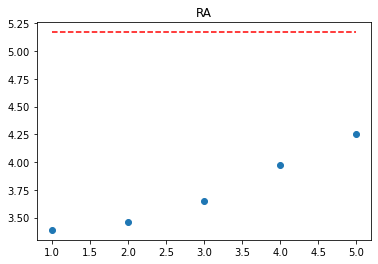

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

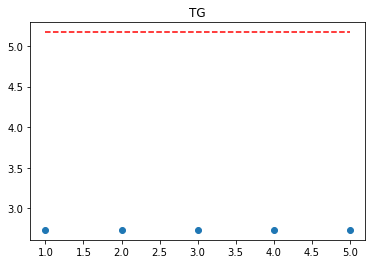

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

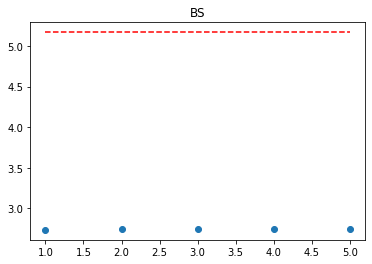

In [41]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_direction', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

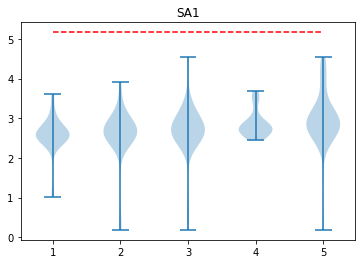

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

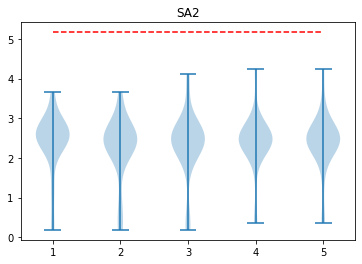

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

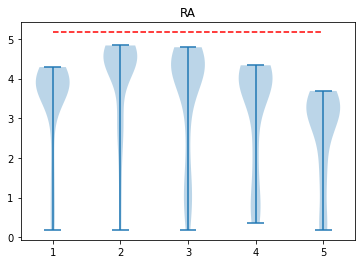

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

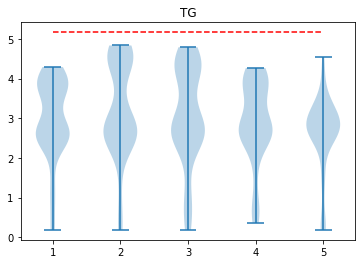

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

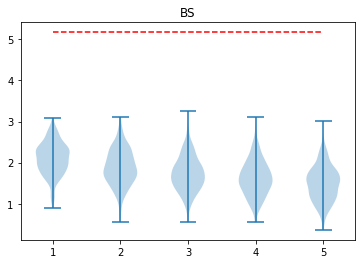

In [57]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_direction', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Distance to basis

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

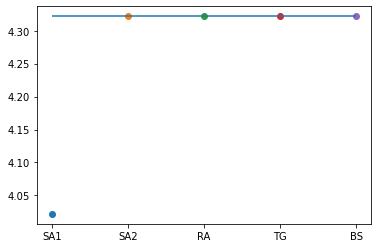

<AxesSubplot:>

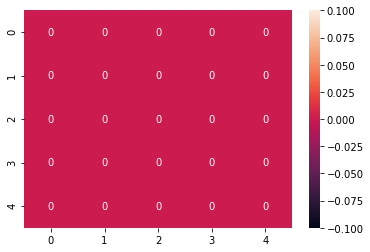

In [169]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
#plt.savefig('./MI/freq_distance_to_basis.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


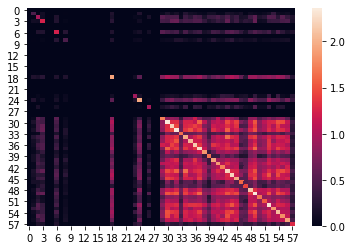

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


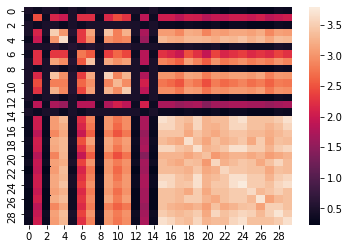

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


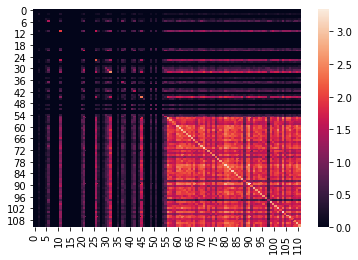

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


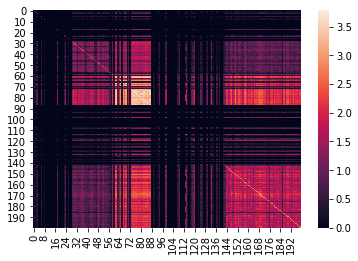

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


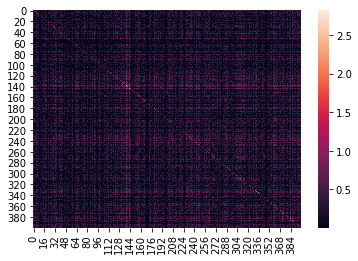

([<matplotlib.axis.XTick at 0x2179e8c90a0>,
 [Text(1, 0, 'SA1'),
  Text(2, 0, 'SA2'),
  Text(3, 0, 'RA'),
  Text(4, 0, 'TG'),
  Text(5, 0, 'BS')])

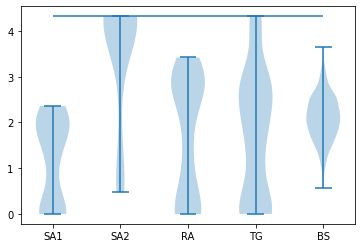

In [171]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_distance_to_basis', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        for k in range(popsize):
            co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    sns.heatmap(co_inf)
    plt.show()
    mi_per_neuron_per_pop.append(mi_per_neuron)
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
#plt.savefig('./MI/single_neuron_d_to_b.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

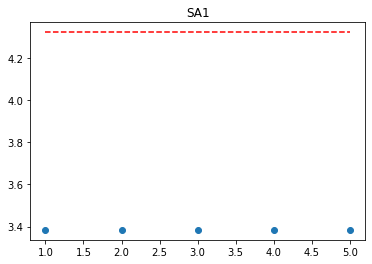

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

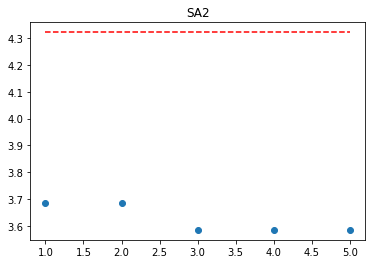

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

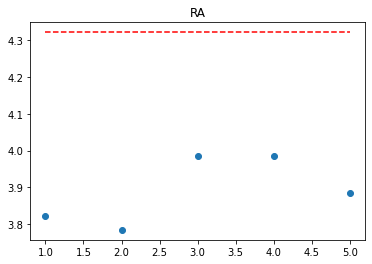

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

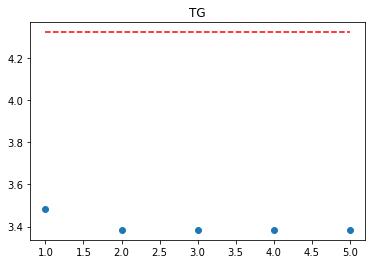

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

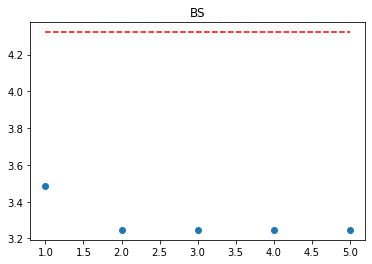

In [42]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_distance_to_basis', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

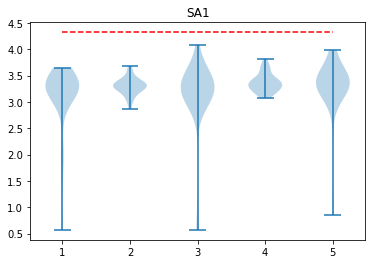

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

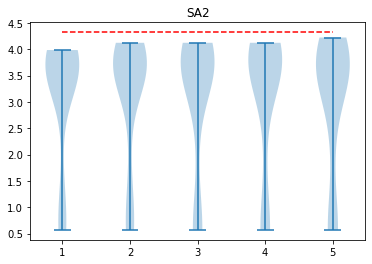

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

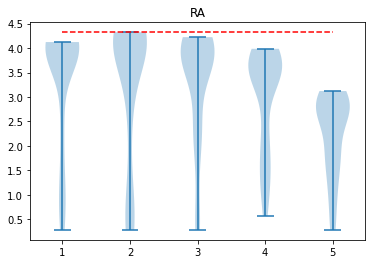

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

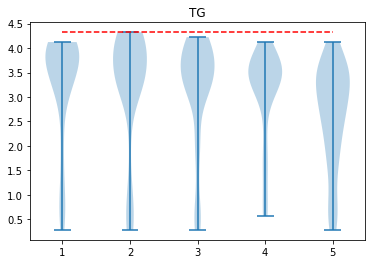

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

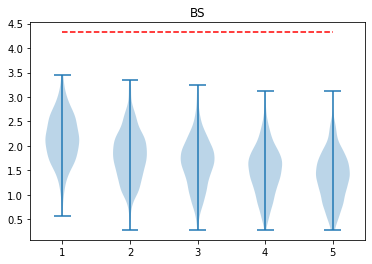

In [58]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_distance_to_basis', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Frequency

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

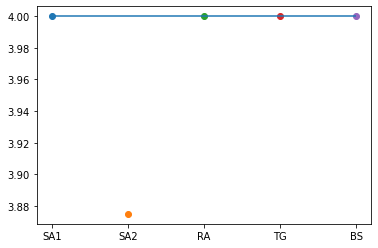

<AxesSubplot:>

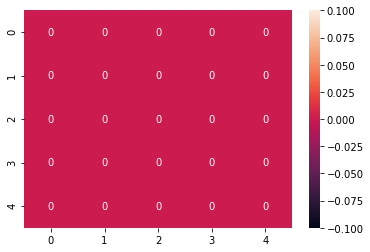

In [172]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
#plt.savefig('./MI/freq_frequency.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


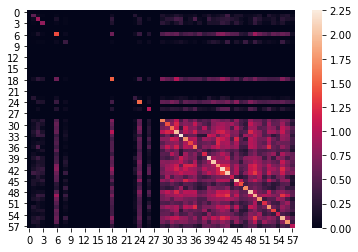

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


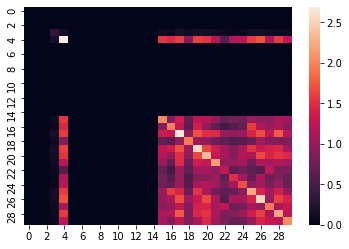

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


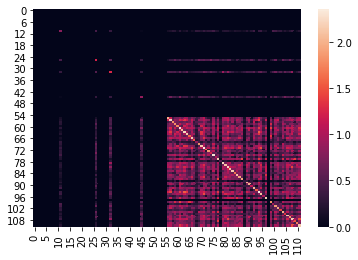

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


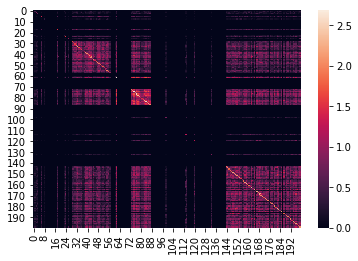

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


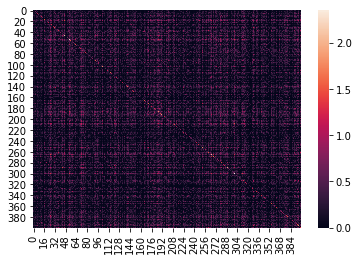

([<matplotlib.axis.XTick at 0x2179e700fd0>,
 [Text(1, 0, 'SA1'),
  Text(2, 0, 'SA2'),
  Text(3, 0, 'RA'),
  Text(4, 0, 'TG'),
  Text(5, 0, 'BS')])

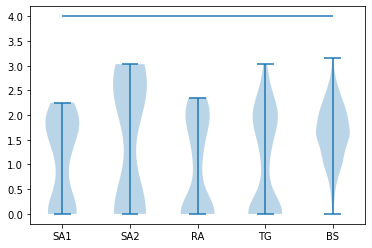

In [174]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_frequency', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        for k in range(popsize):
            co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    sns.heatmap(co_inf)
    plt.show()
    mi_per_neuron_per_pop.append(mi_per_neuron)
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
#plt.savefig('./MI/single_neuron_freq.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

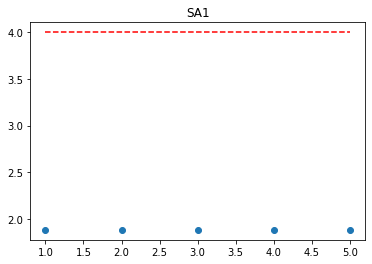

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

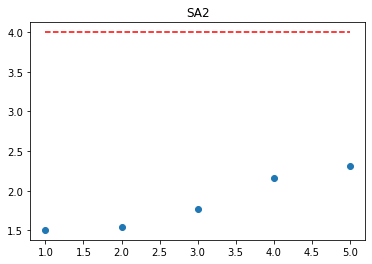

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

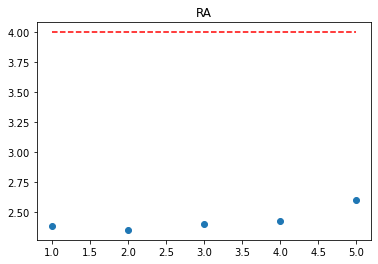

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

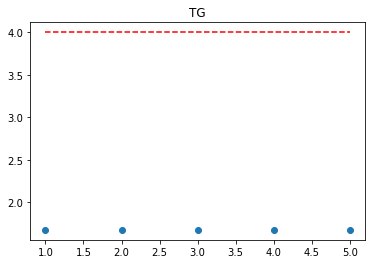

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

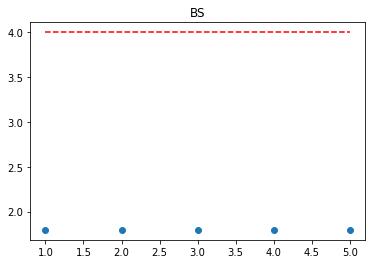

In [43]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_frequency', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

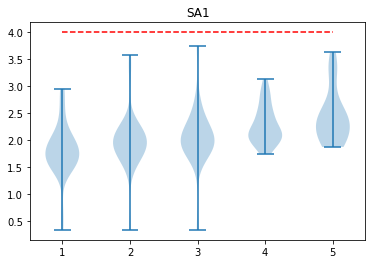

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

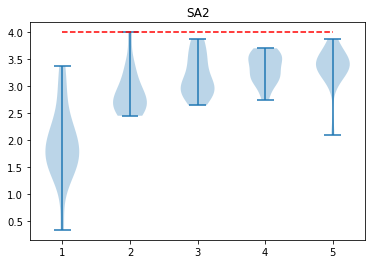

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

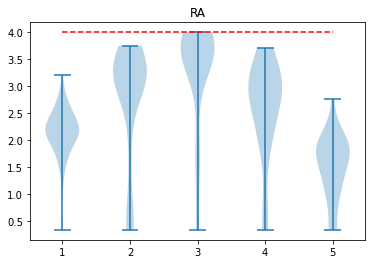

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

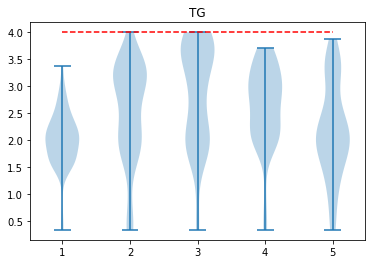

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

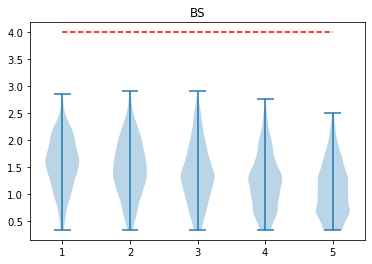

In [59]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_frequency', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

# Slope speed

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list

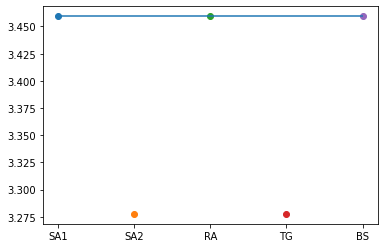

<AxesSubplot:>

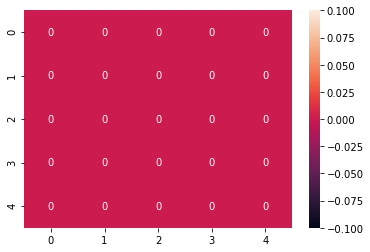

In [175]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]

MI_per_pop = []
for j in range(len(Populations)):
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    MI_per_pop.append(spike_per_neuron_per_stimulus.sum(axis=1))
    plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.hlines(entropy(dist_stim, base=2), 0, 4)
plt.xticks(np.arange(0,5), Populations)
#plt.savefig('./MI/freq_slope.svg')
plt.show()
coinf = np.zeros((5,5))
for i in range(len(Populations)):
    for j in range(len(Populations)):
        coinf[i, j] = co_information(MI_per_pop[i], MI_per_pop[j], dist_stim)
sns.heatmap(coinf, annot=True)

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


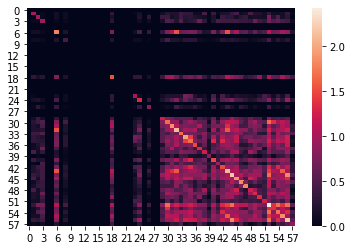

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


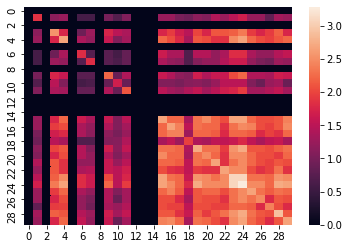

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


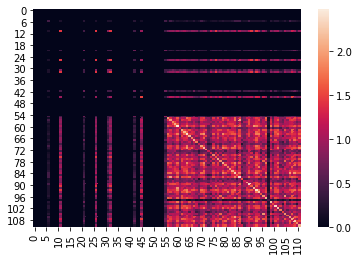

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)


In [ ]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
mi_per_neuron_per_pop = []
for j in range(len(Populations)):
    mi_per_neuron = []
    popsize = Populations_sizes[j]
    neural_act, stim_id = load_data('0_slope_speed', '/' + Populations[j], '/spike_id')
    spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
    for i in range(len(spike_per_neuron_per_stimulus)):
        spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
    co_inf = np.zeros((popsize, popsize))
    for i in range(popsize):
        mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        for k in range(popsize):
            co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
    sns.heatmap(co_inf)
    plt.show()
    mi_per_neuron_per_pop.append(mi_per_neuron)
    #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
    dist_stim = make_dist(np.asarray(stim_id, dtype=int))
    
    #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
plt.violinplot(mi_per_neuron_per_pop)    
plt.hlines(entropy(dist_stim, base=2), 1, 5)
plt.xticks(np.arange(1,6), Populations)
#plt.savefig('./MI/single_neuron_slope.svg')

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

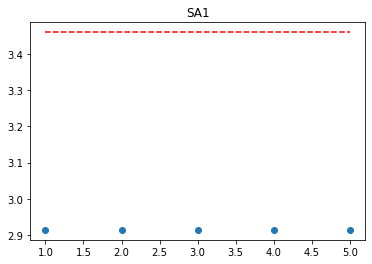

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

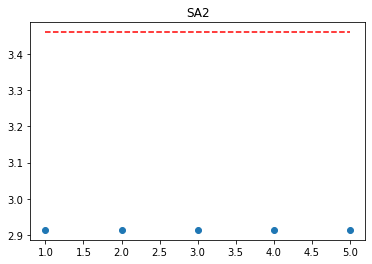

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

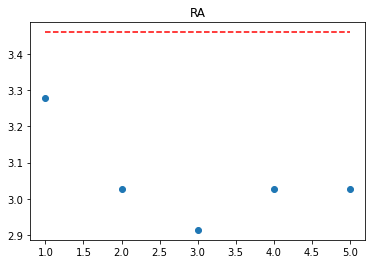

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

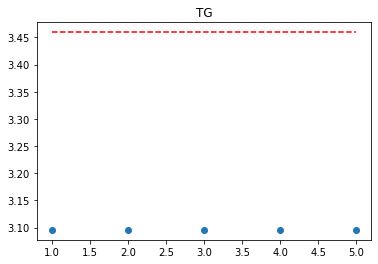

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuo

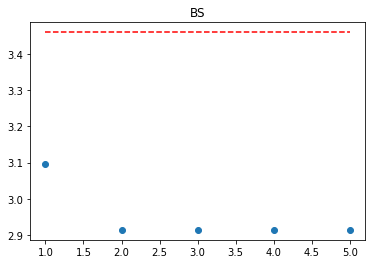

In [44]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
#Within the population
for k in range(len(Populations)):
    mi_per_neuron_per_pop = []
    #Within a rank
    for j in range(ranks):
        sp_time, stim_id = load_spiketimes('0_slope_speed', '/' + Populations[k], j)
        #Within a neuron
        #for i in range(Populations_sizes[k]):
        mi_per_neuron_per_pop.append(mutual_info_score(sp_time, stim_id)/np.log(2))
    plt.scatter(np.arange(1, ranks+1), mi_per_neuron_per_pop)
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()

In [115]:
co_inf.min()

-4.440892098500626e-16

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

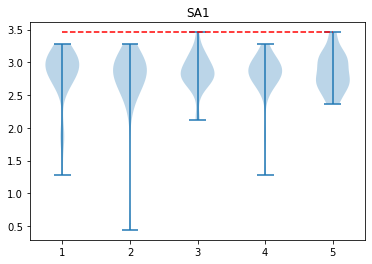

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

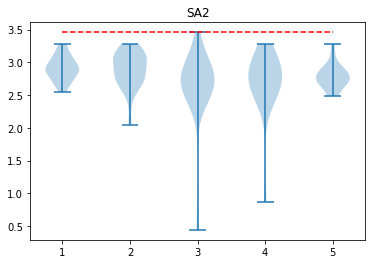

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

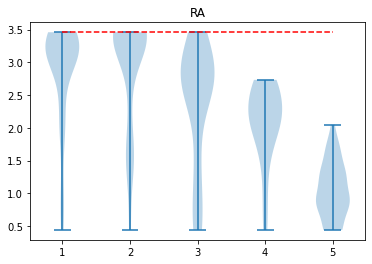

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

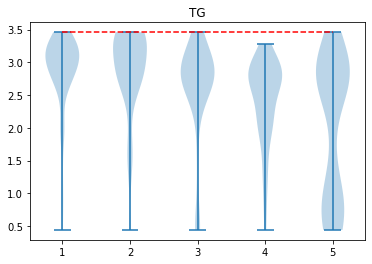

c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\li

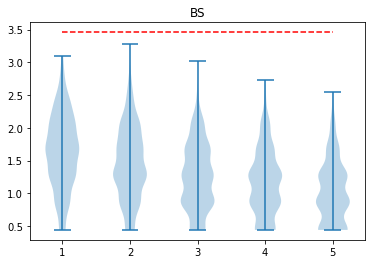

In [55]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Populations_sizes = [58, 30, 112, 200, 400]
ranks = 5
for k in range(len(Populations)):
    mi_per_neuron_per_pop = np.zeros((ranks, Populations_sizes[k]))
    for j in range(ranks):
        neural_act, stim_id = load_spiketime_per_neuron('0_slope_speed', '/' + Populations[k], Populations_sizes[k], j)
        for i in range(Populations_sizes[k]):
            mi_per_neuron_per_pop[j, i] = mutual_info_score(neural_act[:, i], stim_id)/np.log(2)
    plt.violinplot([mi_per_neuron_per_pop[j, mi_per_neuron_per_pop[j, :] > 0] for j in range(ranks)])
    plt.hlines(entropy(make_dist(stim_id), base=2), linestyles='dashed', color='red', xmin=1, xmax=ranks)
    plt.title(Populations[k])
    plt.show()